In [2]:
!pip show transformers
!pip show datasets
!pip show torch
!pip show torchvision

Name: transformers
Version: 5.13.1
Summary: Transformers: the model-definition framework for state-of-the-art machine learning models in text, vision, audio, and multimodal models, for both inference and training.
Home-page: https://github.com/huggingface/transformers
Author: The Hugging Face team (past and future) with the help of all our contributors (https://github.com/huggingface/transformers/graphs/contributors)
Author-email: transformers@huggingface.co
License: Apache 2.0 License
Location: /usr/local/lib/python3.12/dist-packages
Requires: huggingface-hub, numpy, packaging, pyyaml, regex, safetensors, tokenizers, tqdm, typer
Required-by: peft, sentence-transformers
Name: datasets
Version: 4.0.0
Summary: HuggingFace community-driven open-source library of datasets
Home-page: https://github.com/huggingface/datasets
Author: HuggingFace Inc.
Author-email: thomas@huggingface.co
License: Apache 2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: dill, filelock, fsspec, huggi

### Install the required libraries

In [3]:
import pandas as pd
import numpy as np
import torch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments
)

from datasets import Dataset

### Import the database

In [4]:
df = pd.read_csv("/content/amazon_reviews_sentiment.csv")
df.head()

,name,brand,categories,reviews.rating,reviews.title,reviews.text,sentiment
0,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",5.0,Kindle,This product so far has not disappointed. My c...,Positive
1,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",5.0,very fast,great for beginner or experienced person. Boug...,Positive
2,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",5.0,Beginner tablet for our 9 year old son.,Inexpensive tablet for him to use and learn on...,Positive
3,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",4.0,Good!!!,I've had my Fire HD 8 two weeks now and I love...,Positive
4,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",5.0,Fantastic Tablet for kids,I bought this for my grand daughter when she c...,Positive


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59741 entries, 0 to 59740
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            59741 non-null  object 
 1   brand           59741 non-null  object 
 2   categories      59741 non-null  object 
 3   reviews.rating  59741 non-null  float64
 4   reviews.title   59741 non-null  object 
 5   reviews.text    59741 non-null  object 
 6   sentiment       59741 non-null  object 
dtypes: float64(1), object(6)
memory usage: 3.2+ MB


In [6]:
df["sentiment"].value_counts()

,count
sentiment,
Positive,54839
Neutral,2588
Negative,2314


###  Keep only the required columns

In [7]:
df = df[["reviews.text", "sentiment"]]

### Rename them to make the code cleaner:

In [8]:
df = df.rename(columns={
    "reviews.text": "text",
    "sentiment": "label"
})

In [9]:
df.head()

,text,label
0,This product so far has not disappointed. My c...,Positive
1,great for beginner or experienced person. Boug...,Positive
2,Inexpensive tablet for him to use and learn on...,Positive
3,I've had my Fire HD 8 two weeks now and I love...,Positive
4,I bought this for my grand daughter when she c...,Positive


### Check for missing values

In [10]:
# Check for missing values
df.isnull().sum()

,0
text,0
label,0


### Encode the sentiment labels

In [11]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(df["label"])

In [12]:
label_mapping = dict(zip(label_encoder.classes_,
                         label_encoder.transform(label_encoder.classes_)))

print(label_mapping)

{'Negative': np.int64(0), 'Neutral': np.int64(1), 'Positive': np.int64(2)}


### Split the dataset (70% / 15% / 15%)

In [13]:
from sklearn.model_selection import train_test_split

# Features and labels
X = df["text"]
y = df["label"]

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Second split: 15% validation, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

### Verify the split

In [14]:
print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples:", len(X_test))

Training samples: 41818
Validation samples: 8961
Test samples: 8962


In [15]:
print(y_train.value_counts(normalize=True))
print(y_val.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

label
2    0.917954
1    0.043307
0    0.038739
Name: proportion, dtype: float64
label
2    0.917978
1    0.043299
0    0.038723
Name: proportion, dtype: float64
label
2    0.917875
1    0.043405
0    0.038719
Name: proportion, dtype: float64


### Load the BERT Tokenizer

In [16]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

### Create Hugging Face Datasets

In [17]:
train_df = pd.DataFrame({
    "text": X_train,
    "label": y_train
})

val_df = pd.DataFrame({
    "text": X_val,
    "label": y_val
})

test_df = pd.DataFrame({
    "text": X_test,
    "label": y_test
})

In [18]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

### Define the Tokenization Function

In [19]:
def tokenize_function(example):
    return tokenizer(
        example["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

### Tokenize the Datasets

In [20]:
train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/41818 [00:00<?, ? examples/s]

Map:   0%|          | 0/8961 [00:00<?, ? examples/s]

Map:   0%|          | 0/8962 [00:00<?, ? examples/s]

In [21]:
train_dataset.set_format(
    type=None,
    columns=["input_ids", "attention_mask", "token_type_ids", "label"]
)

val_dataset.set_format(
    type=None,
    columns=["input_ids", "attention_mask", "token_type_ids", "label"]
)

test_dataset.set_format(
    type=None,
    columns=["input_ids", "attention_mask", "token_type_ids", "label"]
)

### Remove Unnecessary Columns

In [22]:
train_dataset = train_dataset.remove_columns(["text"])
val_dataset = val_dataset.remove_columns(["text"])
test_dataset = test_dataset.remove_columns(["text"])

### Verify the Tokenized Dataset

In [23]:
print(train_dataset)

Dataset({
    features: ['label', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 41818
})


In [24]:
print(type(train_dataset))

<class 'datasets.arrow_dataset.Dataset'>


In [25]:
train_dataset

Dataset({
    features: ['label', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 41818
})

In [26]:
print(train_dataset.column_names)

['label', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask']


In [27]:
train_dataset = train_dataset.remove_columns(["__index_level_0__"])
val_dataset = val_dataset.remove_columns(["__index_level_0__"])
test_dataset = test_dataset.remove_columns(["__index_level_0__"])

In [28]:
print(train_dataset)
print(train_dataset.features)

Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 41818
})
{'label': Value('int64'), 'input_ids': List(Value('int32')), 'token_type_ids': List(Value('int8')), 'attention_mask': List(Value('int8'))}


### Load the Pre-trained BERT Model

In [29]:
from transformers import BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=3
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### Define Evaluation Metrics

In [30]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted"
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

### Configure Training

In [31]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./bert_results",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=3,

    weight_decay=0.01,

    logging_dir="./logs",
    logging_steps=100,

    load_best_model_at_end=True,

    metric_for_best_model="accuracy",

    greater_is_better=True,

    report_to="none"
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


### Create the Trainer

In [32]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

### Start Training

In [33]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.156296,0.159659,0.945988,0.946934,0.945988,0.945521
2,0.109119,0.162471,0.957482,0.952424,0.957482,0.953808
3,0.085115,0.180266,0.959603,0.956394,0.959603,0.957493


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=7842, training_loss=0.1368717443453539, metrics={'train_runtime': 2876.6255, 'train_samples_per_second': 43.612, 'train_steps_per_second': 2.726, 'total_flos': 8252157676912128.0, 'train_loss': 0.1368717443453539, 'epoch': 3.0})

### Evaluate on the Validation Set

In [34]:
val_results = trainer.evaluate(eval_dataset=val_dataset)

print("Validation Results")
print(val_results)

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.085115,0.180266,3,0.959603,0.956394,0.959603,0.957493


Validation Results
{'eval_loss': 0.1802656203508377, 'eval_accuracy': 0.9596027229103895, 'eval_precision': 0.9563939279528593, 'eval_recall': 0.9596027229103895, 'eval_f1': 0.9574927993659711}


### Evaluate on the Test Set

In [35]:
test_results = trainer.evaluate(eval_dataset=test_dataset)

print("Test Results")
print(test_results)

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.085115,0.208917,3,0.953470,0.950556,0.953470,0.951766


Test Results
{'eval_loss': 0.20891736447811127, 'eval_accuracy': 0.9534702075429592, 'eval_precision': 0.9505560319419359, 'eval_recall': 0.9534702075429592, 'eval_f1': 0.9517663209031499}


### Make Predictions on the Test Set

In [36]:
predictions = trainer.predict(test_dataset)

y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

### Classification Report

In [37]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

    Negative       0.83      0.73      0.78       347
     Neutral       0.53      0.47      0.50       389
    Positive       0.98      0.99      0.98      8226

    accuracy                           0.95      8962
   macro avg       0.78      0.73      0.75      8962
weighted avg       0.95      0.95      0.95      8962



### Confusion Matrix

In [38]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

print(cm)

[[ 253   59   35]
 [  35  183  171]
 [  15  102 8109]]


### Plot the Confusion Matrix

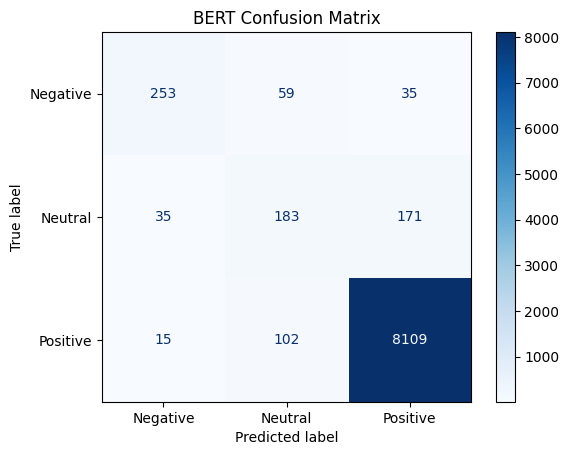

In [39]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues")

plt.title("BERT Confusion Matrix")
plt.show()

### Overall Test Accuracy

In [40]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_true, y_pred)

print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.9535


### Save the Fine-Tuned Model

In [41]:
trainer.save_model("bert_sentiment_model")
tokenizer.save_pretrained("bert_sentiment_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('bert_sentiment_model/tokenizer_config.json',
 'bert_sentiment_model/tokenizer.json')

### Save the Label Encoder

In [42]:
import joblib

joblib.dump(label_encoder, "label_encoder.pkl")

['label_encoder.pkl']